<mark>Replace this with your name and course level (undergraduate/graduate)</mark>

Leonardo Heidi Almeida Murakami

NUSP: 11260186

Undergraduate

<hr>

<mark>Usage of AI generated code</mark>: Did you use or relied on AI generated code? Comment here.

# MAC0460 / MAC5832 (2026) -- EP1: Linear regression

### Objectives:

- to implement and test the iterative solution for the linear regression task
- to understand the core idea of gradient descent based function optimization

### What to do: 
There are some cells that you need to fill in. Some need to be written out completely, others require filling in certain parts.<br>
Remove the code line <tt>raise NotImplementedError()</tt> after filling the cell.

### Submission
Submit the filled notebook, displaying the ouputs of all code cells

### Part I of this EP implements automatic testing

After every task, you will see a test cell to check your solution. We encourage you to experiment with these values to ensure your code is correct

# PART I: Implementing and testing the algorithms

## Notations

$X$ is the data matrix $N \times (d+1)$, with the transposed extended vector $\mathbf{\tilde{x}}$ in the rows

$y$ is the target column vector $N\times 1$

$w$ is the weight vector $(d+1)\times 1$

Note that, for efficiency reasons, you should work with matrices and vectors, and not with individual variables.<br> Most of the functions below can be implemented with just a few lines of code.


In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score


### <mark>1. Write the function that computes the cost</mark>

In [16]:
def compute_cost(X, y, w):
    return np.mean((X @ w - y) ** 2)


In [17]:
X_test = np.array([[1, 2], [1, 3], [1, 4]])
y_test = np.array([[3], [5], [7]])
w_test = np.array([[1], [2]])
print(X_test.shape)
print(y_test.shape)
print(w_test.shape)
expected_cost = 4.0

assert np.isclose(compute_cost(X_test, y_test, w_test), expected_cost), f"Test failed for compute_cost, expected {expected_cost} but got {compute_cost(X_test, y_test, w_test)}"


(3, 2)
(3, 1)
(2, 1)


### <mark>2. Write the function that computes the gradient of the cost function</mark>

In [34]:
def compute_wgrad(X, y, w):
    N = X.shape[0]
    return 2 * X.T @ (X @ w - y) / N

In [35]:
X_test = np.array([[1, 2], [1, 3], [1, 4]])
y_test = np.array([[3], [5], [7]])
w_test = np.array([[1], [2]])
print(X_test.shape)
print(y_test.shape)
print(w_test.shape)
expected_grad = np.array([[4.], [12.]])
assert np.allclose(compute_wgrad(X_test, y_test, w_test), expected_grad), "Test failed for compute_wgrad"


(3, 2)
(3, 1)
(2, 1)


### <mark>3. Write the function that optimizes the cost function</mark>

In [36]:
# Optimization of the cost function based on gradient descent
# Outputs the updated weight vector, weight vector update history, and loss function history
# weight vector update history: it must be a list of the weights, from the initial to the last one
# loss function history: it must be a list of the loss values

def batch_gradient_descent(X, y, w, learning_rate=0.001, num_iters=100):
    w_current = w

    cost_history = [compute_cost(X, y, w)]
    w_history = [w_current]

    for t in range(0, num_iters):
        grad = compute_wgrad(X, y, w_current)
        w_current = w_current - learning_rate * grad
        cost = compute_cost(X, y, w_current)
        cost_history.append(cost)
        w_history.append(w_current)
        if cost < 0.000000001:
            break

    return w_current, w_history, cost_history

In [ ]:
X_test = np.array([[1, 2], [1, 3], [1, 4]])
y_test = np.array([[3], [5], [7]])
w_test = np.array([[0], [0]])
learning_rate = 0.1
num_iters = 10

w_final, w_history, cost_history = batch_gradient_descent(X_test, y_test, w_test, learning_rate, num_iters)
expected_w_final = np.array([[-1.19754351], [-3.21543396]])
expected_cost_history_length = num_iters + 1

assert np.allclose(w_final, expected_w_final, atol=1e-1), f"Test failed for batch_gradient_descent: w_final incorrect, expected {expected_w_final} but got {w_final}"
assert len(cost_history) == expected_cost_history_length, f"Test failed for batch_gradient_descent: cost history length incorrect, expected {expected_cost_history_length} but got {len(cost_history)}"

array([[-1.19754351],
       [-3.21543396]])

### <mark>4. Write the function that computes the prediction</mark>

In [39]:
def compute_prediction(X, w):
    return X @ w


In [40]:
X_test = np.array([[1, 2], [1, 3], [1, 4]])
w_test = np.array([[1], [2]])
expected_prediction = np.array([[5], [7], [9]])

assert np.allclose(compute_prediction(X_test, w_test), expected_prediction), "Test failed for compute_prediction"


# PART II: Solving the linear regression task

Now that all functions are implemented and working, let us test them on our dataset


## Getting the data

We will use the dataset we have collected.

In [41]:
df=pd.read_excel('data_mac0460_5832.xlsx')

df.describe(include='all')

,Sex,Age,Height,Weight,Shoe number
count,340,340.000000,340.000000,340.000000,340.000000
unique,2,NaN,NaN,NaN,NaN
top,Male,NaN,NaN,NaN,NaN
freq,244,NaN,NaN,NaN,NaN
mean,NaN,28.250000,171.529412,71.061765,39.723529
std,NaN,12.908773,10.203057,15.599117,2.704749
min,NaN,3.000000,100.000000,15.000000,24.000000
25%,NaN,21.000000,165.000000,60.000000,38.000000
50%,NaN,23.000000,172.000000,70.000000,40.000000
75%,NaN,29.000000,179.000000,80.000000,42.000000


## Data pre-processing
Typically, we need to prepare the data to be used with ML algoirthms. Some common pre-processing steps involve handling missing dta, outliers, conversion of categorical values to numerical ones, and data normalization/standization.

Data standardization is important in machine learning for several reasons:

- Numerical stability - Large diferences in feature scales can lead to unstable and inaccurate regression coefficients

- Faster convergence - Gradient descent converge faster when features are on a similar scale

- Prevents bias in coefficients - Without normalization, features with larger magnitudes may dominate the model

While not always necessary for simple linear regression, normalization is highly recommended for gradient-based optimization

There are many ways to normalize your data, see [Data Normalization](https://learn.microsoft.com/en-us/azure/machine-learning/component-reference/normalize-data?view=azureml-api-2)

In [42]:
# Replace categorical values (Male/Female) with binary integers (1/0)
df['Sex'] = (df['Sex'] == 'Male').astype(int)

In [ ]:
df.describe(include='all')

In [44]:
# just apply the z-score method. It makes Sex become a floating number ...
df=(df-df.mean())/df.std()
df.describe()

,Sex,Age,Height,Weight,Shoe number
count,3.400000e+02,340.000000,3.400000e+02,3.400000e+02,3.400000e+02
mean,2.089832e-17,0.000000,2.873518e-17,2.089832e-17,3.657205e-17
std,1.000000e+00,1.000000,1.000000e+00,1.000000e+00,1.000000e+00
min,-1.591914e+00,-1.956034,-7.010586e+00,-3.593906e+00,-5.813304e+00
25%,-1.591914e+00,-0.561634,-6.399466e-01,-7.091276e-01,-6.372233e-01
50%,6.263269e-01,-0.406700,4.612228e-02,-6.806569e-02,1.022167e-01
75%,6.263269e-01,0.058100,7.321912e-01,5.729962e-01,8.416568e-01
max,6.263269e-01,4.163835,2.300349e+00,4.932217e+00,2.320537e+00


## <mark>5. First try: select an input feature and a target variable</mark>
Here we select the independent variables (input features) and the depended variable (target)

Let us start with just one input feature ($d=1$)

For the next steps, keep the same target variable and feel free to vary the input feature size

In [45]:
column_names_list = df.columns.tolist()
print(column_names_list)

['Sex', 'Age', 'Height', 'Weight', 'Shoe number']


X shape:  (340, 2)
y shape:  (340, 1)


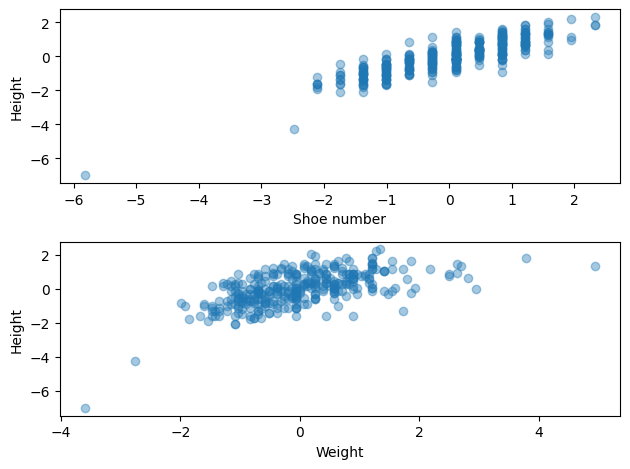

In [97]:
# YOUR code: complete the missing parts or replace where needed

# Choose an input variable
colname = ['Shoe number', 'Weight']

# Build the input data matrix X
X = df.loc[:, colname]
X = X.to_numpy()

# Choose the target variable
targetname = 'Height'
y = df.loc[:, targetname]
y = y.to_numpy()
y = y.reshape((-1,1))

print("X shape: ", X.shape)
print("y shape: ", y.shape)



plt.subplot(2,1,1)
plt.scatter(X[:,0], y, alpha=0.4)
plt.xlabel(colname[0])
plt.ylabel(targetname)

plt.subplot(2,1,2)
plt.scatter(X[:,1], y, alpha=0.4)
plt.xlabel(colname[1])
plt.ylabel(targetname)

plt.tight_layout()

plt.show()


In [102]:
# Training and MSE and R2 score computation
# YOUR code: complete the missing parts or replace where needed

from sklearn.metrics import r2_score

# Choose the initial weights
initial_w = np.array([[1], [2]])  # <---- ?
print("Initial weight:\n", initial_w)

# Feel free to experiment distinct values 
learning_rate = 0.001
iterations = 1000

w, w_history, cost_history = batch_gradient_descent(X, y, initial_w, learning_rate, iterations)
print("Final weight:\n", w)

prediction = compute_prediction(X, w)
mse = ((y - prediction)**2).mean(axis=0).item()
r_2 = r2_score(y, prediction)

print("MSE = %f" %(mse))
print("R2 = ", r_2)

Initial weight:
 [[1]
 [2]]
Final weight:
 [[0.44696813]
 [0.54757076]]
MSE = 0.369903
R2 =  0.6290061252703909


### Now plotting the training loss

In [103]:
# An auxiliary function for plotting
def simple_step_plot(ylist, yname, title, figsize=(4, 4), labels=None):
    y0 = ylist[0]
    x = np.arange(1, len(y0) + 1, 1)
    fig, ax = plt.subplots(1, 1, figsize=figsize)
    for y in ylist:
        ax.plot(x, y)
    plt.xlabel('step')
    plt.ylabel(yname)
    plt.title(title,
              fontsize=14,
              fontweight='bold')
    plt.grid(True)
    if labels is not None:
        plt.legend(labels,
           loc='upper right')
    plt.show()

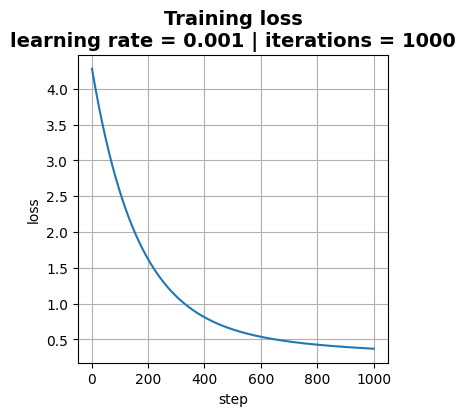

In [104]:
simple_step_plot(
    [cost_history], 'loss',
    'Training loss\nlearning rate = {} | iterations = {}'.format(learning_rate, iterations))

### Plotting the resulting regression line

-5.813303752121026 2.320536888706747
-3.593906246695264 4.932217276496584


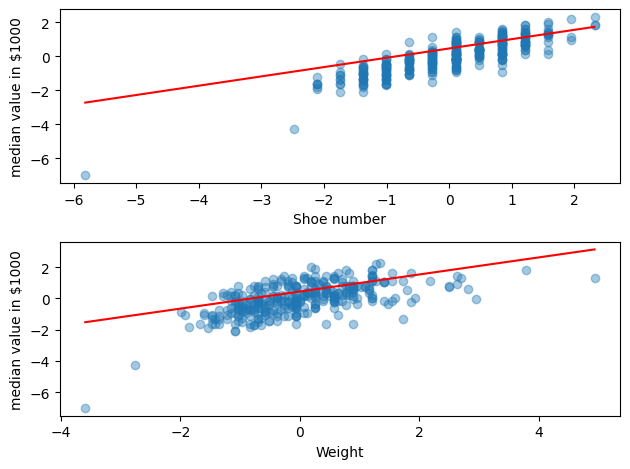

In [107]:
plt.subplot(2,1,1)
plt.scatter(X[:,0], y, alpha=0.4)
min = np.min(X[:,0])
max = np.max(X[:,0])
print(min,max)
x_reg = np.linspace(min,max, 100)
y_reg = w[1]*x_reg + w[0]
plt.plot(x_reg, y_reg, c='r')
plt.xlabel(colname[0])
plt.ylabel('median value in $1000')

plt.subplot(2,1,2)
plt.scatter(X[:,1], y, alpha=0.4)
min = np.min(X[:,1])
max = np.max(X[:,1])
print(min,max)
x_reg = np.linspace(min,max, 100)
y_reg = w[1]*x_reg + w[0]
plt.plot(x_reg, y_reg, c='r')
plt.xlabel(colname[1])
plt.ylabel('median value in $1000')

plt.tight_layout()
plt.show()

## <mark>6. Try input with $d=2$ or more features</mark>

Now, write the code that builds a new X dataset consisting of two or more features and compute the otimized model parameters. Print the weight vector, and the MSE and R2 score, and compare with the results obtained when only one feature was used

In [ ]:
# YOUR CODE HERE

raise NotImplementedError()


### 6.1 Your comments here. In particular, is there a set of input features that clearly is the best one?


## 7. Extra exploration?
- What do you think it will happen if you do not standardize the variable values? What if you use a different standardization method?
- Does weight initialization affect the final result?
- Do number of iterations or learning rate affect the final result?
- Do you think a better prediction is possible if we separate the dataset into Male and Female subgroups and train the algorithm for each subgroup, separately? Try it and comment.
- If you would like to see an animation (not perfect on, though) of how the regression line evolves during training, use the code made available in <tt>EP1_extra.ipynb</tt>